dataset : https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml

| Column | Data type | What I think it represents | Possible role                         |
| ------ | --------- | -------------------------- | ------------------------------------- |
| `TimeStamp`  | str       | Date and Time of transaction     | feature |
| `From Bank`  | int64      |       Origin Bank      |             Graph/entity identifier           |
| `Account`  | str      |      source Account number    |             Graph node identifiers            |
| `To bank`  | int64    |       Destination Bank   |            Graph/entity identifier         |
| `Account.1'  | str      |      Destination Account number    |             Graph node identifiers             |
| `Amount received`  | float64     |       Transaction amount    |             feature       |
| `Recieving currency`  | str      |       Currency unit    |              feature             |
| `Amount Paid`  | float64    |      Transaction amount    |              feature             |
| `Payment currency`  | str      |       Currency unit    |              feature             |
| `Payment format`  | str      |       payment type/ mode   |              feature            |
| `Is laundering`  |    int64  |       Currency unit    |              binary indicator of whether the transaction is labelled as money laundering            |

In [60]:
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
df = pd.read_csv('../data/HI-Small_Trans.csv')


In [3]:
df.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [4]:
df.dtypes

Timestamp                 str
From Bank               int64
Account                   str
To Bank                 int64
Account.1                 str
Amount Received       float64
Receiving Currency        str
Amount Paid           float64
Payment Currency          str
Payment Format            str
Is Laundering           int64
dtype: object

In [5]:
df.columns

Index(['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1',
       'Amount Received', 'Receiving Currency', 'Amount Paid',
       'Payment Currency', 'Payment Format', 'Is Laundering'],
      dtype='str')

In [6]:
df[df['Payment Currency'] != df['Receiving Currency']]

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
1173,2022/09/01 00:22,1362,80030A870,1362,80030A870,52.110000,Euro,61.06,US Dollar,ACH,0
7156,2022/09/01 00:28,11318,800C51010,11318,800C51010,76.060000,Euro,89.12,US Dollar,ACH,0
7925,2022/09/01 00:12,795,800D98770,795,800D98770,17.690000,Australian Dollar,12.52,US Dollar,ACH,0
8467,2022/09/01 00:01,1047,800E92CF0,1047,800E92CF0,19.430000,Euro,22.77,US Dollar,ACH,0
11529,2022/09/01 00:22,11157,80135FFC0,11157,80135FFC0,98.340000,Euro,115.24,US Dollar,ACH,0
...,...,...,...,...,...,...,...,...,...,...,...
5078167,2022/09/10 23:30,23537,803949A90,23537,803949A90,26421.500000,Shekel,7823.96,US Dollar,ACH,0
5078234,2022/09/10 23:59,16163,803638A90,16163,803638A90,47517.490000,Saudi Riyal,12667.62,US Dollar,ACH,0
5078236,2022/09/10 23:55,16163,803638A90,16163,803638A90,11329.850000,Saudi Riyal,3020.41,US Dollar,ACH,0
5078316,2022/09/10 23:44,215064,808F06E11,215064,808F06E10,0.000006,Bitcoin,0.07,US Dollar,ACH,0


In [7]:
diff = df['Amount Received'] - df['Amount Paid']

In [8]:
diff[diff != 0.0]

1173          -8.950000
7156         -13.060000
7925           5.170000
8467          -3.340000
11529        -16.900000
               ...     
5078167    18597.540000
5078234    34849.870000
5078236     8309.440000
5078316       -0.069994
5078318       -0.049996
Length: 72158, dtype: float64

In [9]:
# How many transactions have different currencies?
(df["Payment Currency"] != df["Receiving Currency"]).sum()

np.int64(72170)

In [10]:
# How many unique currencies on each side?
df["Payment Currency"].nunique()
df["Receiving Currency"].nunique()

15

In [11]:
df[diff != 0][[
    "Amount Paid",
    "Payment Currency",
    "Amount Received",
    "Receiving Currency"
]].head(10)

,Amount Paid,Payment Currency,Amount Received,Receiving Currency
1173,61.06,US Dollar,52.11,Euro
7156,89.12,US Dollar,76.06,Euro
7925,12.52,US Dollar,17.69,Australian Dollar
8467,22.77,US Dollar,19.43,Euro
11529,115.24,US Dollar,98.34,Euro
12678,30.62,US Dollar,26.13,Euro
12833,33.21,US Dollar,28.34,Euro
13332,10.73,US Dollar,9.16,Euro
18259,12847.37,Euro,15054.33,US Dollar
18261,3501.30,Euro,4102.77,US Dollar


### Task 2: Data types, Cardinality & Data Quality 

We need to measure missingness before deciding how to handle it.

#### Task 2A: Profile every columns 

In [12]:
features = df.columns

In [13]:
df.nunique()

Timestamp              15018
From Bank              30470
Account               496995
To Bank                15811
Account.1             420636
Amount Received       915161
Receiving Currency        15
Amount Paid           923873
Payment Currency          15
Payment Format             7
Is Laundering              2
dtype: int64

In [14]:
dtypes =df.dtypes.astype(str).tolist()

In [15]:
dtypes

['str',
 'int64',
 'str',
 'int64',
 'str',
 'float64',
 'str',
 'float64',
 'str',
 'str',
 'int64']

In [16]:
missing_count = df.isna().sum().tolist()

In [17]:
missing_count

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [18]:
def print_table(df):
    features = df.columns
    dtypes =df.dtypes.astype(str).tolist()
    unique = df.nunique().tolist()
    missing_count = df.isna().sum().tolist()
    n = len(features)
    total = len(df)
    missing_pct = [(x/total)*100 for x in missing_count]
    print("| Column | dtype | unique | Missing | Missing %|")
    for i in range(n):
        print(f"| {features[i]} | {dtypes[i]} | {unique[i]} | {missing_count[i]} | {missing_pct[i]:.2f}% ")
  

In [19]:
print_table(df)

| Column | dtype | unique | Missing | Missing %|
| Timestamp | str | 15018 | 0 | 0.00% 
| From Bank | int64 | 30470 | 0 | 0.00% 
| Account | str | 496995 | 0 | 0.00% 
| To Bank | int64 | 15811 | 0 | 0.00% 
| Account.1 | str | 420636 | 0 | 0.00% 
| Amount Received | float64 | 915161 | 0 | 0.00% 
| Receiving Currency | str | 15 | 0 | 0.00% 
| Amount Paid | float64 | 923873 | 0 | 0.00% 
| Payment Currency | str | 15 | 0 | 0.00% 
| Payment Format | str | 7 | 0 | 0.00% 
| Is Laundering | int64 | 2 | 0 | 0.00% 


### Task 2B Investigate Indentifiers 

Indentifiers:  
- From Bank: 30470 unique values
- Account: 496995 uv
- To Bank: 15811 uv
- Account.1 : 420636 uv

In [20]:
df['From Bank'].nunique()

30470

In [21]:
df['Account'].nunique()

496995

In [22]:
df['To Bank'].nunique()

15811

In [23]:
df['Account.1'].nunique()

420636

#### Task 2c: investigate the target

In [24]:
counts = df['Is Laundering'].value_counts().tolist()

In [25]:
counts

[5073168, 5177]

In [26]:
Normal_transactions_pct = (counts[0]/sum(counts))*100
Laundering_pct = (counts[1]/sum(counts))*100

In [27]:
print(f"Normal Transactions: {Normal_transactions_pct:.2f}")
print(f"Laundering: {Laundering_pct:.2f}")

Normal Transactions: 99.90
Laundering: 0.10


#### Task 2D: Check actual duplication 

In [28]:
#Total number of duplicated rows
df.duplicated().sum()

np.int64(9)

In [29]:
#View duplicated rows
df[df.duplicated()]

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
863295,2022/09/01 16:20,12004,800C927C1,12004,800C927C0,0.000008,Bitcoin,0.080000,Euro,ACH,0
863296,2022/09/01 16:20,12004,800C927C1,220,813D8C1E1,0.000008,Bitcoin,0.000008,Bitcoin,Bitcoin,0
3684005,2022/09/07 21:25,29992,8099A29B1,220,813725AE1,0.000003,Bitcoin,0.000003,Bitcoin,Bitcoin,0
4166786,2022/09/08 21:05,113779,811144AB1,113779,811144AB0,0.000002,Bitcoin,0.020000,US Dollar,ACH,0
4166787,2022/09/08 21:05,113779,811144AB1,53744,813C777F1,0.000002,Bitcoin,0.000002,Bitcoin,Bitcoin,0
4510480,2022/09/09 10:03,6075,80C702911,6075,80C702910,0.000002,Bitcoin,0.020000,US Dollar,ACH,0
4510481,2022/09/09 10:03,6075,80C702911,154653,814389B61,0.000002,Bitcoin,0.000002,Bitcoin,Bitcoin,0
4816512,2022/09/09 21:33,14433,80935A891,14433,80935A890,0.000001,Bitcoin,0.010000,US Dollar,ACH,0
4816513,2022/09/09 21:33,14433,80935A891,15,813F7AE61,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,0


### Task 2E Timestamp

In [30]:
timestamp = list(df['Timestamp'].sort_values())

In [31]:
timestamp[0]

'2022/09/01 00:00'

In [32]:
timestamp[-1]

'2022/09/18 16:18'

In [33]:
timestamp = df['Timestamp'].sort_values()

In [34]:
timestamp.iloc[0]

'2022/09/01 00:00'

In [35]:
timestamp.iloc[-1]

'2022/09/18 16:18'

## Task 3

### 3.1 Investigate account 

Does Account X share the same banks. Or bank is also unique to the account.

In [36]:
sender_account_banks = (
    df.groupby("Account")["From Bank"]
      .nunique()
)

print("Sender accounts:", sender_account_banks.size)

print(
    "Accounts appearing under multiple sender banks:",
    (sender_account_banks > 1).sum()
)

Sender accounts: 496995
Accounts appearing under multiple sender banks: 4


In [37]:
receiver_account_banks = (
    df.groupby("Account.1")["To Bank"]
      .nunique()
)

print("Receiver accounts:", receiver_account_banks.size)

print(
    "Accounts appearing under multiple receiver banks:",
    (receiver_account_banks > 1).sum()
)

Receiver accounts: 420636
Accounts appearing under multiple receiver banks: 4


In [38]:
print(
    sender_account_banks[sender_account_banks > 1]
    .head(10)
)

Account
80A7FD400    2
80FA55EF0    2
81211BC00    2
8135B8250    2
Name: From Bank, dtype: int64


Account & bank pairs:
100428660 : 70
100428780 : 70

### Task 3B : Sender/receiver identity overlap

In [39]:
sender_ids = (
    df[["From Bank", "Account"]]
    .drop_duplicates()
    .rename(columns={
        "From Bank": "Bank",
        "Account": "Account"
    })
)

print("Unique sender identities:", len(sender_ids))

Unique sender identities: 496999


In [40]:
receiver_ids = (
    df[["To Bank", "Account.1"]]
    .drop_duplicates()
    .rename(columns={
        "To Bank": "Bank",
        "Account.1": "Account"
    })
)

print("Unique receiver identities:", len(receiver_ids))

Unique receiver identities: 420640


In [41]:
overlap = sender_ids.merge(
    receiver_ids,
    on=["Bank", "Account"],
    how="inner"
)

print("Identities appearing as both sender and receiver:", len(overlap))

Identities appearing as both sender and receiver: 402551


### Task 3C : Repeated sender → receiver relationships

In [42]:
pair_cols = [
    "From Bank",
    "Account",
    "To Bank",
    "Account.1"
]

pair_counts = (
    df.groupby(pair_cols, sort=False)
      .size()
)

In [43]:
#Number of unique sender → receiver pairs
print("Total transactions:", len(df))
print("Unique sender→receiver pairs:", len(pair_counts))

Total transactions: 5078345
Unique sender→receiver pairs: 1015736


In [44]:
#Which pairs repeat?
repeated_pairs = pair_counts[pair_counts > 1]

print(
    "Number of repeated sender→receiver pairs:",
    len(repeated_pairs)
)

Number of repeated sender→receiver pairs: 561575


In [45]:
repeated_transactions = repeated_pairs.sum()

print(
    "Transactions belonging to repeated pairs:",
    repeated_transactions
)

Transactions belonging to repeated pairs: 4624184


In [46]:
#Most frequently repeated pair
top_pair = pair_counts.sort_values(ascending=False).head(10)

print(top_pair)

From Bank  Account    To Bank  Account.1
14         80006FCE0  14       80006FCE0    89
113        8000D09B0  113      8000D09B0    69
3          800069AA0  3        800069AA0    66
1          800057020  1        800057020    65
20         8007E86B0  20       8007E86B0    65
220        813424001  220      813424001    63
20         80006AC70  20       80006AC70    62
1          80005B9B0  1        80005B9B0    62
513        8003231B0  513      8003231B0    61
15         8000A6010  15       8000A6010    60
dtype: int64


### Task 3D : Look at one repeated relationship

In [47]:
top_pair_key = pair_counts.idxmax()

print("Most frequent pair:")
print(top_pair_key)

mask = (
    (df["From Bank"] == top_pair_key[0]) &
    (df["Account"] == top_pair_key[1]) &
    (df["To Bank"] == top_pair_key[2]) &
    (df["Account.1"] == top_pair_key[3])
)

df.loc[mask].head(20)

Most frequent pair:
(np.int64(14), '80006FCE0', np.int64(14), '80006FCE0')


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
198117,2022/09/01 00:04,14,80006FCE0,14,80006FCE0,1867230.68,Yuan,1867230.68,Yuan,Reinvestment,0
436379,2022/09/01 03:30,14,80006FCE0,14,80006FCE0,96.97,Euro,761.03,Yuan,ACH,0
436381,2022/09/01 03:50,14,80006FCE0,14,80006FCE0,96.92,Euro,760.62,Yuan,ACH,0
638580,2022/09/01 09:49,14,80006FCE0,14,80006FCE0,405.21,Yuan,405.21,Yuan,Cheque,0
638581,2022/09/01 09:32,14,80006FCE0,14,80006FCE0,2992.32,Yuan,2992.32,Yuan,Credit Card,0
638582,2022/09/01 09:38,14,80006FCE0,14,80006FCE0,1183.55,Yuan,1183.55,Yuan,Cash,0
789995,2022/09/01 14:08,14,80006FCE0,14,80006FCE0,1959.29,Yuan,1959.29,Yuan,Cheque,0
789996,2022/09/01 14:29,14,80006FCE0,14,80006FCE0,4404.26,Yuan,4404.26,Yuan,Credit Card,0
789997,2022/09/01 14:09,14,80006FCE0,14,80006FCE0,4777.78,Yuan,4777.78,Yuan,Cash,0
933562,2022/09/01 18:48,14,80006FCE0,14,80006FCE0,394.53,US Dollar,2642.42,Yuan,ACH,0


Node:
Bank + Account

Edge:
Directed transaction from sender → receiver

Edge attributes:
Amount
Timestamp
Payment currency
Receiving currency
Payment format
Is Laundering

## Day 2

### Task 2.1 Data integrity

Are there obvious data-quality problems in the raw transaction data?

In [48]:
#Check 1 : missing values
missing_count = df.isna().sum()
cols = df.columns[df.isna().any()]
print(f"Total missing values:\n{missing_count}")
print(f"Columns containing missing values: {'none' if cols.empty else cols.tolist()}")

Total missing values:
Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64
Columns containing missing values: none


Check exact duplicates
Are the 9 rows completely identical, and are they potentially legitimate repeated transactions?


In [49]:
dups = df[df.duplicated(keep=False)]

print("Rows involved in exact duplicates:", len(dups))

Rows involved in exact duplicates: 18


In [50]:
dups.sort_values(
    ["From Bank", "Account", "To Bank", "Account.1", "Timestamp"]
)

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
4510478,2022/09/09 10:03,6075,80C702911,6075,80C702910,0.000002,Bitcoin,0.020000,US Dollar,ACH,0
4510480,2022/09/09 10:03,6075,80C702911,6075,80C702910,0.000002,Bitcoin,0.020000,US Dollar,ACH,0
4510479,2022/09/09 10:03,6075,80C702911,154653,814389B61,0.000002,Bitcoin,0.000002,Bitcoin,Bitcoin,0
4510481,2022/09/09 10:03,6075,80C702911,154653,814389B61,0.000002,Bitcoin,0.000002,Bitcoin,Bitcoin,0
863294,2022/09/01 16:20,12004,800C927C1,220,813D8C1E1,0.000008,Bitcoin,0.000008,Bitcoin,Bitcoin,0
863296,2022/09/01 16:20,12004,800C927C1,220,813D8C1E1,0.000008,Bitcoin,0.000008,Bitcoin,Bitcoin,0
863293,2022/09/01 16:20,12004,800C927C1,12004,800C927C0,0.000008,Bitcoin,0.080000,Euro,ACH,0
863295,2022/09/01 16:20,12004,800C927C1,12004,800C927C0,0.000008,Bitcoin,0.080000,Euro,ACH,0
4816511,2022/09/09 21:33,14433,80935A891,15,813F7AE61,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,0
4816513,2022/09/09 21:33,14433,80935A891,15,813F7AE61,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,0


Records are exact duplicates

#### Check 2.3

In [51]:
print("Negative Amount Paid:", (df["Amount Paid"] < 0).sum())
print("Negative Amount Received:", (df["Amount Received"] < 0).sum())
print("Zero Amount Paid:", (df["Amount Paid"] == 0).sum())
print("Zero Amount Received:", (df["Amount Received"] == 0).sum())

Negative Amount Paid: 0
Negative Amount Received: 0
Zero Amount Paid: 0
Zero Amount Received: 0


#### Check 2.4
When they differ, do the payment and receiving currencies also differ?

In [52]:
#Check if currrencies are same
currencies_same = (df['Payment Currency']== df['Receiving Currency'])
#same amounts 
amount_same = (df['Amount Paid'] - df['Amount Received']).abs() < 1e-9

currencies_different = (df['Payment Currency'] != df['Receiving Currency'])
amount_different = (df['Amount Paid'] - df['Amount Received']).abs() >= 1e-9

In [53]:
pd.crosstab(index = currencies_same, columns= amount_same, rownames=["Currency Same"],
    colnames=["Amount Same"])

Amount Same,False,True
Currency Same,,
False,72158,12
True,0,5006175


In [54]:
pd.crosstab(index = currencies_same, columns= amount_different, rownames=["Currency Same"],
    colnames=["Amount Different"])

Amount Different,False,True
Currency Same,,
False,12,72158
True,5006175,0


In [55]:
pd.crosstab(index = currencies_different, columns= amount_different, rownames=["Currency Different"],
    colnames=["Amount Different"])

Amount Different,False,True
Currency Different,,
False,5006175,0
True,12,72158


In [56]:
pd.crosstab(index = currencies_different, columns= amount_same, rownames=["Currency Different"],
    colnames=["Amount Same"])

Amount Same,False,True
Currency Different,,
False,0,5006175
True,72158,12


The raw dataset contains 0 missing values, 9 exact duplicate rows, no zero/negative transactions.
Amount differences are closely associated with currency differences. There were no same currency tranaction with different numerical amount, while all transactions with different currencies also hada different numerical amounts; only 12 cross-currency transactions had equal numerical amounts.

### Task 2.2 Numerial + categorical polling

In [58]:
# Numerical columns 
numerical_cols = df[['Amount Paid', 'Amount Received']]


In [68]:
numerical_cols.describe(percentiles=[0.25, 0.50 ,0.75, 0.90, 0.95, 0.99, 0.999])

,Amount Paid,Amount Received
count,5078345.00,5078345.00
mean,4509273.37,5988726.07
std,869772830.92,1037183108.89
min,0.00,0.00
25%,184.48,183.37
50%,1414.54,1411.01
75%,12297.84,12346.27
90%,137275.31,140736.77
95%,623757.22,649906.51
99%,13524530.71,14751232.46


| headers| Amount Paid | Amount Received |
| :--- | :---: | ---: |
| Mean | 4509273.37 | 5988726.07 |
| Median | 1414.54	 | 1411.01 |


If mean > median ->  right skewed.   
medan < median -> left skewed.   
mean = median -> symmetrical.   
Hence the values of both Amount Paid and Amount Receieved are right skewed.

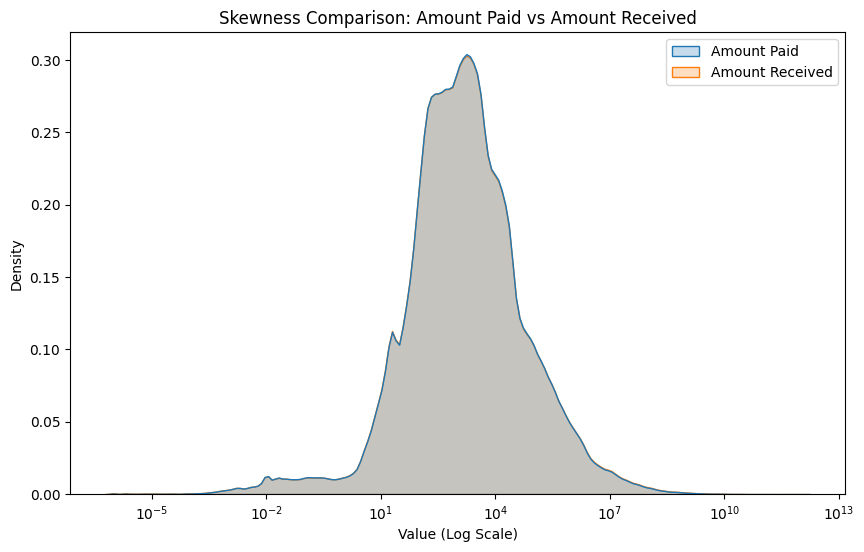

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Plot both columns on the same chart with transparency
sns.kdeplot(data=df[['Amount Paid', 'Amount Received']], log_scale=True, fill=True, common_norm=False)

plt.title('Skewness Comparison: Amount Paid vs Amount Received')
plt.xlabel('Value (Log Scale)')
plt.ylabel('Density')
plt.show()

Because the line continues all the way to the edge of the chart on the right, it visually proves the presence of a continuous "heavy tail." 

In [74]:
categorical_columns = df[['Payment Currency', 'Receiving Currency', 'Payment Format']]

In [ ]:
cat_count = categorical_columns['Payment Currency'].nunique()
frequencies = df['Payment Currency'].value_counts()
proportions = df['Payment Currency'].value_counts(normalize= True) # values between 0 and 1

print(f'Number of categories in : {cat_count}  ')


In [87]:
def cat_analysis(categorical_columns):
    for col in categorical_columns:
        cat_count = categorical_columns[col].nunique()
        frequencies = df[col].value_counts()
        proportions = df[col].value_counts(normalize= True) # values between 0 and 1
        print(f"====== {col} Analysis ====== ")
        print(f'Number of categories : {cat_count}  ')
        print(f"\n-----------------------------\n")
        print(f"{col} Frequencies \n {frequencies}")
        print(f"\n-----------------------------\n")
        print(f"{col} Percentages \n {proportions * 100}")
        print(f"\n==============\n")


In [86]:
cat_analysis(categorical_columns)

====== Payment Currency Analysis ====== 
Number of categories : 15  

-----------------------------

Payment Currency Frequencies 
 Payment Currency
US Dollar            1895172
Euro                 1168297
Swiss Franc           234860
Yuan                  213752
Shekel                192184
Rupee                 190202
UK Pound              180738
Yen                   155209
Ruble                 155178
Bitcoin               146066
Canadian Dollar       140042
Australian Dollar     136769
Mexican Peso          110159
Saudi Riyal            89014
Brazil Real            70703
Name: count, dtype: int64

-----------------------------

Payment Currency Percentages 
 Payment Currency
US Dollar           37.32
Euro                23.01
Swiss Franc          4.62
Yuan                 4.21
Shekel               3.78
Rupee                3.75
UK Pound             3.56
Yen                  3.06
Ruble                3.06
Bitcoin              2.88
Canadian Dollar      2.76
Australian Dollar    2.6

“Transaction amounts are right skewed; the median is less than relative to the mean.”
“The payment system contains 15 currencies and 7 payment formats, with 'cheques' being the most frequent category.”

### Task 2.3 : Target + Relationship Analysis